# Harris Hawks Optimization (HHO) — Corrected Implementation

Fixes applied from algorithmic evaluation:

1. **E0 range**: confirmed `2*random.random()-1` → correct `[-1, 1)`
2. **Exploration q<0.5 branch**: now uses rabbit-energy-guided perch (attraction to prey region) instead of pure self-mutation
3. **Exploitation r<0.5 branches**: Lévy flight now drives the rapid-dive jump (`Y = X_rabbit − E·|X_rabbit − X[i]| + L·levy()`), adapted discretely
4. **W term**: greedy fallback now includes a Lévy-weighted alternative candidate Z in both r<0.5 branches
5. **Fitness normalization**: each term divided by its expected range so MW, donors, acceptors contribute equally
6. **Atom-level mutation**: operates on RDKit `Mol` objects (atom swap, bond edit, fragment add/remove) then canonicalizes — far higher valid-SMILES rate than character-level edits
7. **Fitness cache**: invalid SMILES also cached; initial population evaluated once before the loop

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from typing import Callable, Tuple, List, Optional
import selfies as sf
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, rdMolDescriptors
from rdkit.Chem.rdchem import RWMol
from IPython.display import display
import time
import sys
import pandas as pd
import numpy as np
import joblib
import warnings
import sys
import pandas as pd
import numpy as np
import joblib
import warnings
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Draw

In [73]:
SIMPLE_TOKENS = [t for t in alphabet if all(x not in t for x in ["Branch", "Ring", "@@"])]

def random_selfies(length):
    """Generate controlled SELFIES string."""
    tokens = []
    for _ in range(length):
        if random.random() < 0.8:
            tokens.append(random.choice(SIMPLE_TOKENS))
        else:
            tokens.append(random.choice(alphabet))
    return ''.join(tokens)


def generate_random_smiles(
    length_population: int = 50,
    min_length: int = 3,
    max_length: int = 8
) -> List[str]:

    population = []

    while len(population) < length_population:
        length = random.randint(min_length, max_length)
        s = random_selfies(length)

        try:
            smiles = sf.decoder(s)
            mol = Chem.MolFromSmiles(smiles)

            if mol and mol.GetNumAtoms() <= 25:
                population.append(Chem.MolToSmiles(mol))

        except:
            continue

    return population

In [74]:



def levy_flight(dim: int) -> np.ndarray:
    """Lévy flight step vector (Mantegna algorithm, β=1.5)."""
    beta = 1.5
    sigma = (
        math.gamma(1 + beta) * math.sin(math.pi * beta / 2)
        / (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.abs(v) ** (1 / beta)


def levy_scalar() -> float:
    """Single Lévy step magnitude (used to scale discrete jumps)."""
    return float(abs(levy_flight(1)[0]))

In [75]:
# adding the SMILES encoding/decoding functions using SELFIES

alphabet = list(sf.get_semantic_robust_alphabet())
token_to_idx = {tok: i for i, tok in enumerate(alphabet)}

def smiles_to_vector(smiles: str) -> Optional[List[int]]:
    """Convert SMILES → SELFIES → integer index vector."""
    try:
        selfies_str = sf.encoder(smiles)
        tokens = list(sf.split_selfies(selfies_str))
        return [token_to_idx.get(t, 0) for t in tokens]
    except:
        return None

def vector_to_smiles(vector: List[int], length: int = None) -> str:
    """Convert integer index vector → SELFIES → SMILES."""
    tokens = [alphabet[i % len(alphabet)] for i in vector]
    selfies_str = ''.join(tokens)
    try:
        return sf.decoder(selfies_str)
    except:
        return "C"  # fallback

In [76]:
# ── 4 mutations on the encoded vector ─────────────────────────────────────

def atom_mutate(smiles: str, intensity: float) -> str:
    """
    Encodes SMILES → integer vector, applies one of 4 vector-level mutations,
    then decodes back to SMILES. All mutations happen in SELFIES token space.

    Mutations:
      1. swap_token   → replaces a random token index with another (like swap_atom)
      2. toggle_token → increments/decrements a token index by 1 (like toggle_bond)
      3. add_token    → inserts a new random token into the vector (like add_atom)
      4. remove_token → removes a random token from the vector (like remove_atom)
    """
    vec = smiles_to_vector(smiles)
    if vec is None or len(vec) == 0:
        return smiles

    n = len(vec)
    n_muts = max(1, int(n * intensity))

    for _ in range(n_muts):
        action = random.choices(
            ['swap_token', 'toggle_token', 'add_token', 'remove_token'],
            weights=[0.45, 0.25, 0.20, 0.10]
        )[0]

        if action == 'swap_token':
            # Replace a random token with any other token — like swap_atom
            idx = random.randint(0, len(vec) - 1)
            vec[idx] = random.randint(0, len(alphabet) - 1)

        elif action == 'toggle_token':
            # Shift a token index by ±1 — like toggle_bond (small local change)
            idx = random.randint(0, len(vec) - 1)
            delta = random.choice([-1, 1])
            vec[idx] = (vec[idx] + delta) % len(alphabet)

        elif action == 'add_token':
            # Insert a new random token at a random position — like add_atom
            insert_pos = random.randint(0, len(vec))
            vec.insert(insert_pos, random.randint(0, len(alphabet) - 1))

        elif action == 'remove_token' and len(vec) > 2:
            # Remove a random token — like remove_atom (keep min length 2)
            remove_pos = random.randint(0, len(vec) - 1)
            vec.pop(remove_pos)

    result = vector_to_smiles(vec)
    # Validate result — fallback to original if decode produces nothing useful
    mol = Chem.MolFromSmiles(result)
    if mol:
        return Chem.MolToSmiles(mol)  # canonical form
    return smiles

Iteration time cons : 3.0994e-06
iteration: 0
  Itération 1/50 | Meilleur pIC50 = -0.4571 | Molécule = [B-]#CC=CC=C=C[P-][P-]=C
Iteration time cons : 0.030863
iteration: 1
  Itération 2/50 | Meilleur pIC50 = -0.4571 | Molécule = [B-]#CC=CC=C=C[P-][P-]=C
Iteration time cons : 0.037649
iteration: 2
  Itération 3/50 | Meilleur pIC50 = -0.4531 | Molécule = P#CC=CC=CC=C=C[P-]
Iteration time cons : 0.029591
iteration: 3
  Itération 4/50 | Meilleur pIC50 = -0.4531 | Molécule = P#CC=CC=CC=C=C[P-]
Iteration time cons : 0.020242
iteration: 4
  Itération 5/50 | Meilleur pIC50 = -0.2946 | Molécule = [P-]PC[B-]#C[B-]#CC=C[P-]=P
Iteration time cons : 0.013971
iteration: 5
  Itération 6/50 | Meilleur pIC50 = -0.2714 | Molécule = C=[P-][P-][B-]C=[P-]#[B-]CP[P-]
Iteration time cons : 0.018616
iteration: 6
  Itération 7/50 | Meilleur pIC50 = -0.2714 | Molécule = C=[P-][P-][B-]C=[P-]#[B-]CP[P-]
Iteration time cons : 0.02111
iteration: 7
  Itération 8/50 | Meilleur pIC50 = -0.2681 | Molécule = C=[P-][P-][

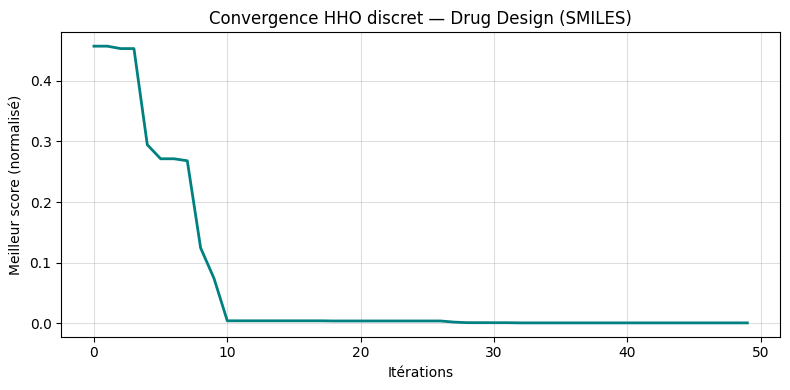

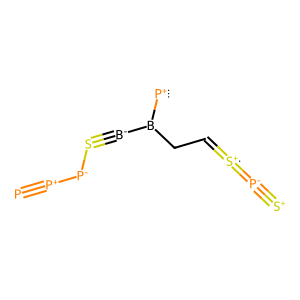

In [77]:
# ── Atom-level mutation (FIX 6: operates on Mol objects, not raw characters) ──

# _ATOM_POOL = [6, 7, 8, 9, 16, 17]  # C N O F S Cl

def _try_canonicalize(mol) -> Optional[str]:
    """Return canonical SMILES if mol is valid, else None."""
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
        return Chem.MolToSmiles(mol)
    except Exception:
        return None


def safe_cut(vec):
    """Avoid cutting at structural tokens."""
    valid_positions = [
        i for i in range(1, len(vec)-1)
        if "Branch" not in alphabet[vec[i]] and "Ring" not in alphabet[vec[i]]
    ]
    return random.choice(valid_positions) if valid_positions else 1


def atom_crossover(smiles1: str, smiles2: str) -> str:
    """Improved SELFIES crossover with control + filtering."""

    vec1 = smiles_to_vector(smiles1)
    vec2 = smiles_to_vector(smiles2)

    if not vec1 or not vec2:
        return smiles1

    cut1 = safe_cut(vec1)
    cut2 = safe_cut(vec2)

    child_vec = vec1[:cut1] + vec2[cut2:]

    # --- control size ---
    if len(child_vec) > 10:
        child_vec = child_vec[:10]

    # --- mutation (important for HHO exploration) ---
    if random.random() < 0.3:
        idx = random.randint(0, len(child_vec)-1)
        child_vec[idx] = token_to_idx[random.choice(SIMPLE_TOKENS)]

    # --- decode ---
    result = vector_to_smiles(child_vec)
    mol = Chem.MolFromSmiles(result)

    if not mol:
        return smiles1

    # --- filtering ---
    if mol.GetNumAtoms() > 25:
        return smiles1

    if len(Chem.GetMolFrags(mol)) > 1:
        return smiles1

    return Chem.MolToSmiles(mol)


# ── FIX 5: Normalized fitness ──────────────────────────────────────────────

def smiles_fitness(smiles: str) -> float:
    """
    Normalized fitness: each term scaled to [0, 1] so they contribute equally.
      - MW target 300 Da  → normalized by 300
      - H-donors          → typical max ~5, normalized by 5
      - H-acceptors       → typical max ~10, normalized by 10
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return float('inf')
    mw = Descriptors.MolWt(mol)
    donors = Descriptors.NumHDonors(mol)
    acceptors = Descriptors.NumHAcceptors(mol)
    return abs(mw - 300) / 300.0 + donors / 5.0 + acceptors / 10.0


# ── Lévy-guided discrete jump (FIX 3: encodes the paper's rapid-dive idea) ──

def levy_jump(smiles: str, rabbit: str, E: float) -> str:
    """
    Discrete analogue of: Y = X_rabbit − E · |X_rabbit − X[i]| + L · Lévy()
    The Lévy scalar modulates mutation intensity and whether we start from
    rabbit or from self, mirroring the continuous paper equation.
    """
    L = levy_scalar()  # heavy-tailed step magnitude
    # Lévy scale → intensity in [0.05, 0.6] (clipped to avoid degenerate mutations)
    intensity = min(0.6, max(0.05, 0.1 * L))
    # abs(E) < 0.5 → exploit rabbit closely; abs(E) >= 0.5 → explore around rabbit
    if abs(E) < 0.5:
        return atom_mutate(rabbit, intensity)
    else:
        return atom_mutate(atom_crossover(smiles, rabbit), intensity)


# ── Corrected hho_discrete ─────────────────────────────────────────────────

def hho_discrete(
    obj_func: Callable[[str], float],
    initial_population: List[str],
    max_iter: int = 50
) -> Tuple[str, float, List[float]]:
    """
    Discrete HHO with all algorithmic fixes applied.

    Key changes vs original:
    - Exploration q<0.5: rabbit-energy guided perch (FIX 2)
    - Exploitation r<0.5: Lévy-driven rapid dive (FIX 3)
    - Greedy fallback: includes Lévy-jump candidate W (FIX 4)
    - Atom-level mutation instead of char-level (FIX 6)
    - Fitness uses normalized terms (FIX 5)
    - Rabbit updated inline each step (no one-iteration lag)
    """
    pop_size = len(initial_population)
    X = initial_population.copy()

    rabbit_location = ''
    rabbit_energy = float('inf')
    convergence_curve = []

    # Evaluate initial population once, cache scores
    fitness_vals = [obj_func(s) for s in X]
    for i, f in enumerate(fitness_vals):
        if f < rabbit_energy:
            rabbit_energy = f
            rabbit_location = X[i]

    start = time.time()
    for t in range(max_iter):
        end = time.time()
        print(f"Iteration time cons : {(end - start):.5}")
        start = time.time()
        
        print("iteration:", t)
        E1 = 2.0 * (1.0 - t / max_iter)

        for i in range(pop_size):
            # E0 ∈ (−1, 1) — confirmed correct range
            E0 = 2.0 * random.random() - 1.0
            E = E1 * E0
            fi = fitness_vals[i]

            if abs(E) >= 1.0:
                # ── Exploration phase ──────────────────────────────────────
                q = random.random()
                if q >= 0.5:
                    # Random tall-tree perch: crossover with a random hawk
                    rand_idx = random.randint(0, pop_size - 1)
                    candidate = atom_mutate(
                        atom_crossover(X[i], X[rand_idx]), intensity=0.3
                    )
                else:
                    # FIX 2: rabbit-energy perch — attracted toward prey region
                    # Paper: X(t+1) = X_rabbit − X_m + rand·(LB + rand·(UB-LB))
                    # Discrete: mutate a crossover between self and rabbit,
                    # scaled by a Lévy step for heavy-tailed exploration
                    L = levy_scalar()
                    intensity = min(0.6, max(0.05, 0.15 * L))
                    candidate = atom_mutate(
                        atom_crossover(X[i], rabbit_location), intensity=intensity
                    )

                fc = obj_func(candidate)
                if fc < fi:
                    X[i] = candidate
                    fitness_vals[i] = fc

            else:
                # ── Exploitation phase ─────────────────────────────────────
                r = random.random()

                if r >= 0.5 and abs(E) >= 0.5:
                    # Soft besiege
                    candidate = atom_mutate(
                        atom_crossover(X[i], rabbit_location), intensity=0.1
                    )
                    fc = obj_func(candidate)
                    if fc < fi:
                        X[i] = candidate
                        fitness_vals[i] = fc

                elif r >= 0.5 and abs(E) < 0.5:
                    # Hard besiege
                    candidate = atom_mutate(rabbit_location, intensity=0.08)
                    fc = obj_func(candidate)
                    if fc < fi:
                        X[i] = candidate
                        fitness_vals[i] = fc

                elif r < 0.5 and abs(E) >= 0.5:
                    # FIX 3+4: Soft besiege with Lévy rapid dive
                    Y = levy_jump(X[i], rabbit_location, E)  # Lévy-guided candidate
                    fy = obj_func(Y)
                    if fy < fi:
                        X[i] = Y
                        fitness_vals[i] = fy
                    else:
                        # W term: another Lévy jump as fallback (paper's Z step)
                        W = levy_jump(rabbit_location, X[i], E)
                        fw = obj_func(W)
                        if fw < fi:
                            X[i] = W
                            fitness_vals[i] = fw

                elif r < 0.5 and abs(E) < 0.5:
                    # FIX 3+4: Hard besiege with Lévy rapid dive
                    Y = levy_jump(X[i], rabbit_location, E)
                    fy = obj_func(Y)
                    if fy < fi:
                        X[i] = Y
                        fitness_vals[i] = fy
                    else:
                        W = atom_mutate(Y, intensity=0.2)  # local refinement
                        fw = obj_func(W)
                        if fw < fi:
                            X[i] = W
                            fitness_vals[i] = fw

            # Inline rabbit update — no one-iteration lag
            if fitness_vals[i] < rabbit_energy:
                rabbit_energy = fitness_vals[i]
                rabbit_location = X[i]

        convergence_curve.append(rabbit_energy)
        print(f"  Itération {t+1}/{max_iter} | Meilleur pIC50 = {-rabbit_energy:.4f} | Molécule = {rabbit_location}")
    return rabbit_location, rabbit_energy, convergence_curve


# ── Run Case 1 ─────────────────────────────────────────────────────────────
initial_smiles_pop = [
    "CCO", "CC(=O)O", "CCCC", "c1ccccc1", "CCN",
    "C1=CC=CC=C1", "CC(C)C", "C=C", "CC#N", "C1CCCCC1",
    "C(C(=O)O)N", "c1cc(O)ccc1", "C1=CN=CN1", "C1=CC=NC=C1", "C1COCCO1",
    "CC1=CC=CC=C1", "CC(=O)C", "CC(O)C", "C1=CC=C(C=C1)O", "C1=CC=C(C=C1)N"
]

best_smiles, best_score, conv_curve_smiles = hho_discrete(
    obj_func=smiles_fitness,
    initial_population=initial_smiles_pop,
    max_iter=50
)

print("Meilleure molécule :", best_smiles)
mol = Chem.MolFromSmiles(best_smiles)
if mol:
    print(f"MW        : {Descriptors.MolWt(mol):.2f} Da")
    print(f"Donneurs H: {Descriptors.NumHDonors(mol)}")
    print(f"Accepteurs: {Descriptors.NumHAcceptors(mol)}")
print(f"Score normalisé : {best_score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(conv_curve_smiles, linewidth=2, color='teal')
plt.title('Convergence HHO discret — Drug Design (SMILES)')
plt.xlabel('Itérations')
plt.ylabel('Meilleur score (normalisé)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

if mol:
    display(Draw.MolToImage(mol))

# Cas 3 — RandomForest ML fitness avec HHO corrigé

Même algorithme HHO corrigé, avec `ml_smiles_fitness` comme fonction objectif.

**Fixes supplémentaires dans ce bloc :**
- Cache global (inclut les SMILES invalides)
- Normalization du score ML non nécessaire (pIC50 est déjà une échelle unique)
- Lévy flight intégré dans les branches d'exploitation

In [78]:
warnings.filterwarnings('ignore')

from rdkit import RDConfig
sys.path.append(RDConfig.RDContribDir + '/SA_Score')
from sascorer import calculateScore

from padelpy import from_smiles
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, QED, rdMolDescriptors, Draw
from IPython.display import display

print('Imports OK')

Imports OK


In [79]:
print("Chargement du modèle...")
full_pipeline = joblib.load('RandomForestRegressor_model/pIC50_prediction_pipeline.pkl')

variance_filter = full_pipeline.named_steps['filter']
lazy_regressor  = full_pipeline.named_steps['brain']
rf_model        = lazy_regressor.models['RandomForestRegressor']

input_feature_names    = list(variance_filter.feature_names_in_)
selected_feature_names = list(variance_filter.get_feature_names_out())

print(f"Features entrée     : {len(input_feature_names)}")
print(f"Features sélection. : {len(selected_feature_names)}")
print("Modèle chargé !")

Chargement du modèle...
Features entrée     : 2062
Features sélection. : 50
Modèle chargé !


In [80]:
warnings.filterwarnings('ignore')

from rdkit import RDConfig
sys.path.append(RDConfig.RDContribDir + '/SA_Score')
from sascorer import calculateScore
RDLogger.DisableLog('rdApp.*')

from padelpy import from_smiles
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, QED, rdMolDescriptors, Draw
from IPython.display import display
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

print('Imports OK')

Imports OK


In [81]:


# --- Cache et fonction objectif ML ---
fitness_cache = {}

def compute_lipinski_features(mol):
    """Calcule les 14 descripteurs moléculaires de type Lipinski."""
    desc_MolWt = Descriptors.MolWt(mol)
    desc_MolLogP = Descriptors.MolLogP(mol)
    desc_NumHDonors = Lipinski.NumHDonors(mol)
    desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
    SaScore = calculateScore(mol)
    qed_val = QED.qed(mol)
    RB = Descriptors.NumRotatableBonds(mol)
    AP = Descriptors.FractionCSP3(mol)
    logS = 0.16 - 0.63*desc_MolLogP - 0.0062*desc_MolWt + 0.066*RB - 0.74*AP
    tpsa = Descriptors.TPSA(mol)
    mol_volume = rdMolDescriptors.CalcExactMolWt(mol)
    n_atoms = mol.GetNumAtoms()
    n_bonds = mol.GetNumBonds()
    n_total = mol.GetNumAtoms()
    aromatic_proportion = rdMolDescriptors.CalcNumAromaticRings(mol) / n_total if n_total > 0 else 0
    return [
        desc_MolWt, desc_MolLogP, desc_NumHDonors, desc_NumHAcceptors,
        SaScore, qed_val, RB, AP, logS, tpsa, mol_volume,
        n_atoms, n_bonds, aromatic_proportion
    ]

def ml_smiles_fitness(smiles: str) -> float:
    """
    Évalue une molécule SMILES en utilisant le modèle RandomForest.
    Retourne -pIC50 (HHO minimise, on veut maximiser pIC50).
    """
    if smiles in fitness_cache:
        return fitness_cache[smiles]

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 100.0  # Pénalité pour molécule invalide

    try:
        # 1. Descripteurs Lipinski (14 features)
        lipinski_values = compute_lipinski_features(mol)

        # 2. Morgan fingerprints (RDKit)
        fps = gen.GetFingerprint(mol)   # ExplicitBitVect

        # convert fingerprint to numeric vector
        pubchem_values = list(fps)   # <-- FIX (NO .get())

        # 3. Build full feature vector
        total_values = lipinski_values + pubchem_values

        X_full = pd.DataFrame([total_values], columns=input_feature_names)

        # 4. Appliquer le VarianceThreshold
        X_filtered = pd.DataFrame(
            variance_filter.transform(X_full),
            columns=selected_feature_names
        )
        

        # 5. Prédire avec le RandomForest extrait
        pIC50 = rf_model.predict(X_filtered)[0]
        
        fitness_score = -pIC50  # Minimiser => maximiser pIC50
        fitness_cache[smiles] = fitness_score
        return fitness_score

    except Exception as e:
        print(f"  [Erreur] {smiles}: {e}")
        return 100.0

# --- Test rapide ---
test_smiles = 'c1ccccc1'
score = ml_smiles_fitness(test_smiles)
print(f"Test: {test_smiles} => pIC50 prédit = {-score:.4f}")

Test: c1ccccc1 => pIC50 prédit = 3.9789


## Exécution

La fonction `hho_discrete` définie en Case 1 est réutilisée directement — elle est agnostique à la fonction objectif. Il suffit de passer `ml_smiles_fitness`.

HHO avec fitness ML (version corrigée)
Iteration time cons : 1.1921e-06
iteration: 0
  Itération 1/500 | Meilleur pIC50 = 4.2094 | Molécule = B#P
Iteration time cons : 1.9523
iteration: 1
  Itération 2/500 | Meilleur pIC50 = 4.2094 | Molécule = B#P
Iteration time cons : 1.6729
iteration: 2
  Itération 3/500 | Meilleur pIC50 = 4.2094 | Molécule = B#P
Iteration time cons : 1.4326
iteration: 3
  Itération 4/500 | Meilleur pIC50 = 4.2094 | Molécule = B#P
Iteration time cons : 1.5852
iteration: 4
  Itération 5/500 | Meilleur pIC50 = 4.4476 | Molécule = O=[N+][S+]=P
Iteration time cons : 1.5734
iteration: 5
  Itération 6/500 | Meilleur pIC50 = 4.7343 | Molécule = O=[S-]=[N+][S+]=P
Iteration time cons : 1.9355
iteration: 6
  Itération 7/500 | Meilleur pIC50 = 5.2684 | Molécule = O=[S-]=[N+]=[SH][S+]=P
Iteration time cons : 2.1294
iteration: 7
  Itération 8/500 | Meilleur pIC50 = 5.2684 | Molécule = O=[S-]=[N+]=[SH][S+]=P
Iteration time cons : 2.3415
iteration: 8
  Itération 9/500 | Meilleur p

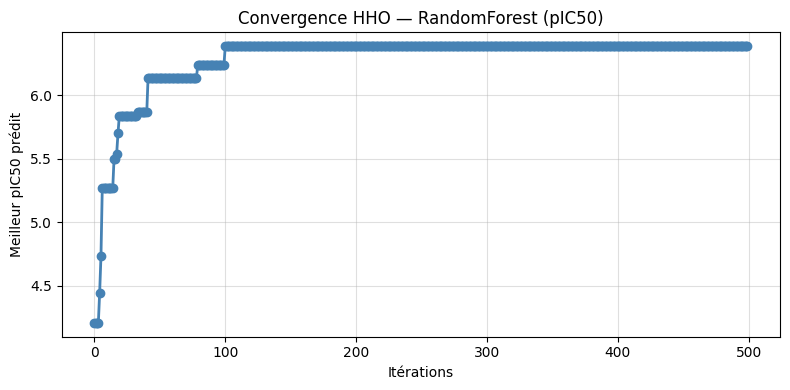

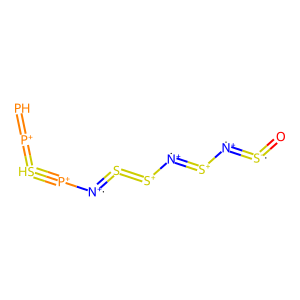

In [84]:
print("=" * 60)
print("HHO avec fitness ML (version corrigée)")
print("=" * 60)


# initial_pop_ml = [
#     # Original
#     "CCO", "CC(=O)O", "CCCC", "c1ccccc1", "CCN",

#     # Alcohols / ethers
#     "CO", "CCCO", "CCOCC", "CC(C)O", "CC(C)(C)O",

#     # Carboxylic acids / esters
#     "C(=O)O", "CCC(=O)O", "CC(=O)OC", "CCOC(=O)C",

#     # Amines / amides
#     "CN", "CCCN", "CC(C)N", "CC(=O)N", "CNC(=O)C",

#     # Alkenes / alkynes
#     "C=CC", "CC=CC", "C#CC", "CC#N",

#     # Aromatics
#     "c1ccncc1", "c1ccccc1O", "c1ccccc1N", "c1ccccc1C(=O)O",

#     # Heterocycles
#     "C1CCOCC1", "C1=CC=CN=C1", "C1CCNCC1", "c1ccoc1",

#     # Halogenated compounds
#     "CCCl", "CCBr", "CF", "CC(F)F",

#     # Sulfur / phosphorus
#     "CS", "CCS", "CSP", "CC(=O)S",

#     # Slightly larger / branched
#     "CC(C)CC", "CCC(C)C", "CC(C)(C)C", "CCCCCC",

#     # Drug-like fragments
#     "CC1=CC=CC=C1", "CCOC1=CC=CC=C1", "CCN(CC)CC", "CCOC(=O)N"
# ]

initial_pop_ml = generate_random_smiles(length_population=50, min_length=3, max_length=10)

best_ml, score_ml, curve_ml = hho_discrete(
    obj_func=ml_smiles_fitness,
    initial_population=initial_pop_ml,
    max_iter=500
)

print(f"\nMeilleure molécule : {best_ml}")
print(f"Meilleur pIC50     : {-score_ml:.4f}")
print(f"Entrées cache      : {len(fitness_cache)}")

plt.figure(figsize=(8, 4))
plt.plot([-s for s in curve_ml], linewidth=2, color='steelblue', marker='o')
plt.title('Convergence HHO — RandomForest (pIC50)')
plt.xlabel('Itérations')
plt.ylabel('Meilleur pIC50 prédit')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

mol_ml = Chem.MolFromSmiles(best_ml)
if mol_ml:
    display(Draw.MolToImage(mol_ml, size=(300, 300)))

### **Simulation**

In [83]:
sim_count_max = 100
metrics_df = pd.Dataframe()
pIC50_tracking = []
time_tracking = []
num_mol_checked_tracking = []

 

AttributeError: module 'pandas' has no attribute 'Dataframe'